In [ ]:
import pandas as pd
import numpy as np
import scipy.signal as signal
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.dates import DateFormatter, date2num
from matplotlib.lines import Line2D

### API from OpenWeatherMap for Mashhad

In [ ]:
"""api_key = 'a789125a4e865b16b2d16034e054b6d1'

city = ("Mashhad")

url = f'http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}'

response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    temp = data['main']['temp'] - 273
    pressure = data["main"]["pressure"]
    humidity = data["main"]["humidity"]
    print(f"Temperature: {temp:.2f}",'\n' "Pressure:", pressure,'\n' "Humidity:", humidity)
else:
    print('Error fetching weather data')"""

Temperature: 24.23 
Pressure: 1017 
Humidity: 25


In [ ]:
# CSV for Ground Temperature & Humidity: EM300-TH sensor data.
df_TH = pd.read_csv('thingsboard_EM300-TH-13-10.csv')
# CSV for Soil Moisture, Temperature, and EC: EM500-SMTC sensor data.
df_SMTC = pd.read_csv('thingsboard_EM500-SMTC_13-10.csv')
# CSV for Water Container EM500-UDL sensor data.
df_UDL = pd.read_csv('thingsboard_EM500-UDL_data.csv')
# CSV for normalized water container capacity EM500-UDL sensor data.
df_power = pd.read_csv('thingsboard_UC300_4-20ma.csv')
df_liter = pd.read_csv('container.csv') # For Filled Liter
df_timestamp = pd.read_csv('distance.csv') # For Timestamp
df_water_container = pd.read_csv('water_container.csv') 
df_merged = pd.read_csv('last_merged.csv') 

### Merging Dataframes

### Data Null Check

### Scatter plot for Soil SMTC-300 Sensor

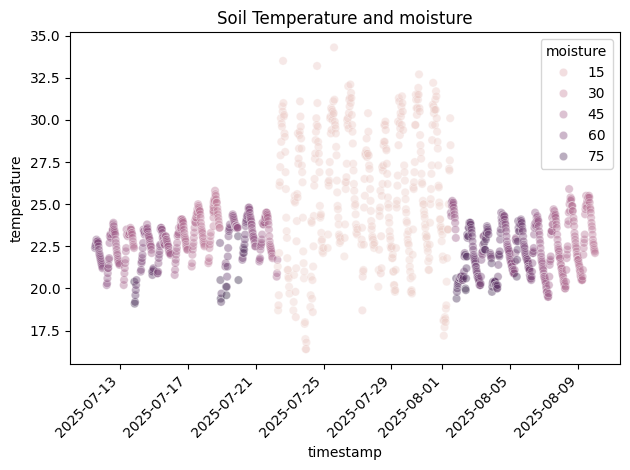

In [6]:
df_SMTC["timestamp"] = pd.to_datetime(df_SMTC["timestamp"])
start_date = '2025-07-11 00:00:00'
end_date = '2025-08-11 00:00:00'
filtered_df = df_SMTC[(df_SMTC['timestamp'] >= start_date) & (df_SMTC["timestamp"] <= end_date)].copy()
sns.scatterplot(data = filtered_df, x = "timestamp", y = "temperature", hue = "moisture", alpha = 0.4)
plt.title("Soil Temperature and moisture", loc= "center")
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

### Scatter plot for Air TH-300 Sensor

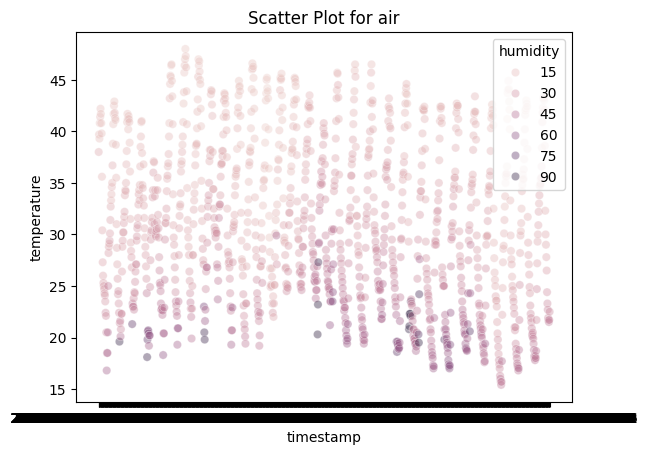

In [7]:
sns.scatterplot(data = df_TH, x = "timestamp", y = "temperature", hue = "humidity", alpha = 0.4)
plt.title("Scatter Plot for air")
plt.show()

### Detecting outliers based on Z-score(Colapsed)

In [12]:
df_container_copy = df_liter.copy()
z = np.abs(stats.zscore(df_container_copy["slope"], axis = 0, nan_policy="raise"))
threshhold = 3
df_container_copy = df_container_copy[z<threshhold]
sns.scatterplot(data = df_container_copy, x = "timestamp", y = "slope", alpha = 0.4)
plt.title("Scatter Plot for Container")
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()


ValueError: The input contains nan values

### Healthy Scatter plot for Water Container

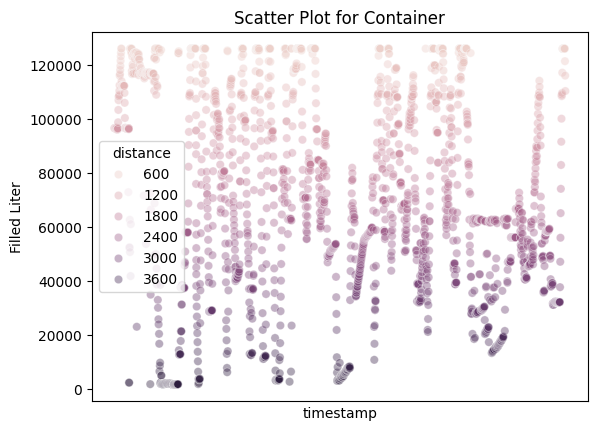

In [19]:
#df_liter["timestamp"] = pd.to_datetime(df_liter["timestamp"])
df_container_healthy = df_liter.copy()
threshhold = 4000
outlier_mask = df_container_healthy["distance"] > threshhold
df_container_healthy = df_container_healthy[~outlier_mask]
sns.scatterplot(data = df_container_healthy, x = "timestamp", y = "Filled Liter", hue= "distance", alpha = 0.4)
plt.xticks(rotation=45)
plt.tick_params(
    axis='x',   
    which='both',     
    bottom=False,     
    labelbottom=False )
plt.title("Scatter Plot for Container")
plt.show()

### Time-based Healthy Water 

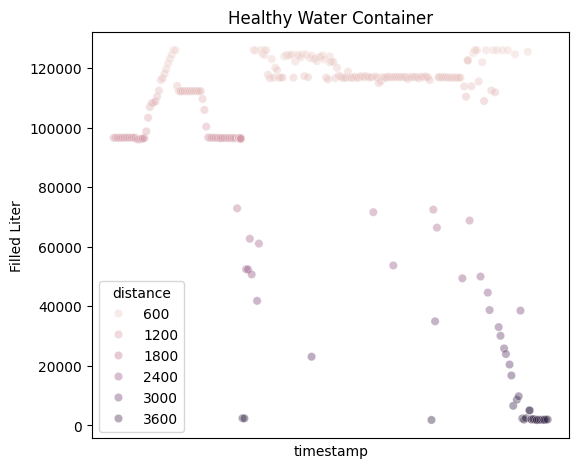

In [18]:
start_date = '2025-07-13 11:00:00'
end_date = '2025-07-15 17:00:00'
filtered_df = df_container_healthy[(df_container_healthy['timestamp'] > start_date) & (df_container_healthy["timestamp"] < end_date)].copy()

sns.scatterplot(data = filtered_df, x = "timestamp", y = "Filled Liter", hue="distance", alpha = 0.4)
plt.tight_layout()
plt.title("Healthy Water Container")

plt.xticks(rotation=45)
plt.tick_params(
    axis='x',   
    which='both',     
    bottom=False,     
    labelbottom=False)

plt.show()


1868


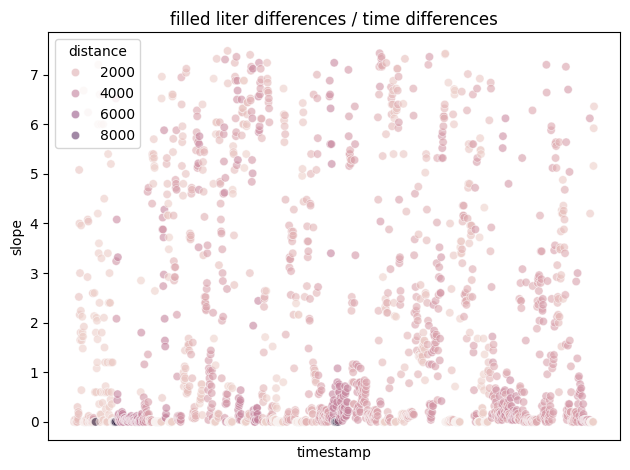

In [22]:
#start_date = '2025-07-13 11:00:00'
#end_date = '2025-07-15 17:00:00'
df_liter = pd.read_csv('water_container.csv')
#filtered_df = df_liter[(df_liter['timestamp'] > start_date) & (df_liter["timestamp"] < end_date)].copy()
threshhold = 7.5
filtered_df = df_liter.loc[df_liter['slope'] < threshhold]

print(len(filtered_df))
sns.scatterplot(data = filtered_df, x = "timestamp", y = "slope", hue="distance", alpha = 0.6)
plt.title("filled liter differences / time differences")
plt.ylabel("slope")

plt.xticks(rotation=45)
plt.tick_params(
    axis='x',   
    which='both',     
    bottom=False,     
    labelbottom=False 
)

plt.tight_layout()
plt.show()

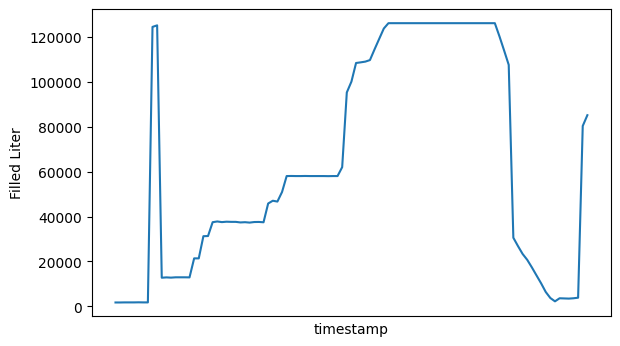

In [69]:
start_date = '2025-07-16 18:00:00'
end_date = '2025-07-18 20:00:00'

filtered_df = pd.read_csv('healthy_slope.csv')
filtered_df = filtered_df[(filtered_df['timestamp'] > start_date) & (filtered_df["timestamp"] < end_date)].copy()

threshhold = 7
filtered_df = filtered_df.loc[filtered_df['slope'] < threshhold]

threshhold_2 = 0
filtered_df = filtered_df.loc[filtered_df['Filled Liter'] > threshhold_2]

sns.lineplot(data=filtered_df, x="timestamp", y="Filled Liter")
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.tick_params(
    axis='x',   
    which='both',     
    bottom=False,     
    labelbottom=False 
)
plt.show()

In [66]:
filtered_df['Filled Liter'].min()

np.int64(1656)

### 